In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

<h1 style="font-size:40px; color:blue;">Data</h1>

In [3]:
df = pd.read_csv(r"C:\Users\nobyz\Downloads\sm_risk_data.csv")
df.head()

,credit_amount,business_age_months,monthly_income_avg,total_deposits_3m,revenue_volatility_3m,request_ratio,dti_monthly,nsf_count_3m,negative_days_3m,owner_percentage,owner_credit_score,p_viable,risk_sharp
0,65119.01,14,31423.29,86800.05,0.745,2.072,0.542,1,3,77.8,571,0.835,0
1,36058.07,94,27885.55,79161.32,0.552,1.293,0.434,3,3,84.4,731,0.918,0
2,9782.59,32,13293.69,42202.89,0.650,0.736,0.432,4,3,81.8,604,0.466,0
3,31340.25,30,18121.27,51841.87,0.726,1.729,0.306,5,7,53.8,729,0.495,1
4,14167.70,32,13954.20,42403.16,0.597,1.015,0.311,3,4,66.7,663,0.608,0


<h1 style="font-size:40px; color:blue;">info</h1>

In [4]:
df.columns

Index(['credit_amount', 'business_age_months', 'monthly_income_avg',
       'total_deposits_3m', 'revenue_volatility_3m', 'request_ratio',
       'dti_monthly', 'nsf_count_3m', 'negative_days_3m', 'owner_percentage',
       'owner_credit_score', 'p_viable', 'risk_sharp'],
      dtype='object')

In [5]:
df.isna().sum()

credit_amount            0
business_age_months      0
monthly_income_avg       0
total_deposits_3m        0
revenue_volatility_3m    0
request_ratio            0
dti_monthly              0
nsf_count_3m             0
negative_days_3m         0
owner_percentage         0
owner_credit_score       0
p_viable                 0
risk_sharp               0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   credit_amount          5000 non-null   float64
 1   business_age_months    5000 non-null   int64  
 2   monthly_income_avg     5000 non-null   float64
 3   total_deposits_3m      5000 non-null   float64
 4   revenue_volatility_3m  5000 non-null   float64
 5   request_ratio          5000 non-null   float64
 6   dti_monthly            5000 non-null   float64
 7   nsf_count_3m           5000 non-null   int64  
 8   negative_days_3m       5000 non-null   int64  
 9   owner_percentage       5000 non-null   float64
 10  owner_credit_score     5000 non-null   int64  
 11  p_viable               5000 non-null   float64
 12  risk_sharp             5000 non-null   int64  
dtypes: float64(8), int64(5)
memory usage: 507.9 KB


In [7]:
df.dtypes

credit_amount            float64
business_age_months        int64
monthly_income_avg       float64
total_deposits_3m        float64
revenue_volatility_3m    float64
request_ratio            float64
dti_monthly              float64
nsf_count_3m               int64
negative_days_3m           int64
owner_percentage         float64
owner_credit_score         int64
p_viable                 float64
risk_sharp                 int64
dtype: object

<h1 style="font-size:40px; color:blue;">balance</h1>

In [8]:
df['risk_sharp'].value_counts()

risk_sharp
0    2661
1    2339
Name: count, dtype: int64

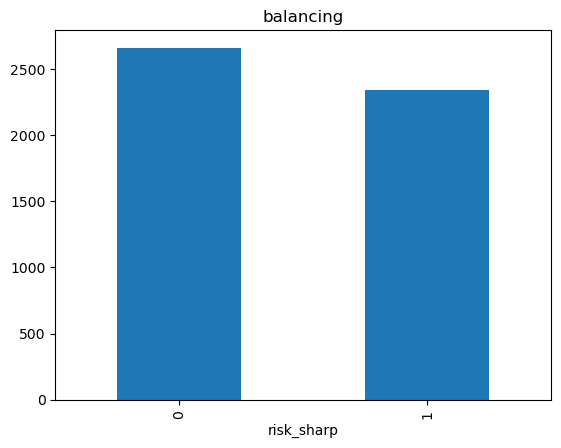

In [9]:
df['risk_sharp'].value_counts().plot(kind='bar')
plt.title("balancing")
plt.show()

<h1 style="font-size:40px; color:blue;">analysis</h1>

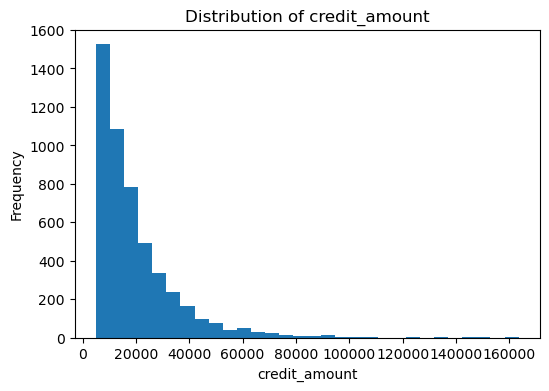

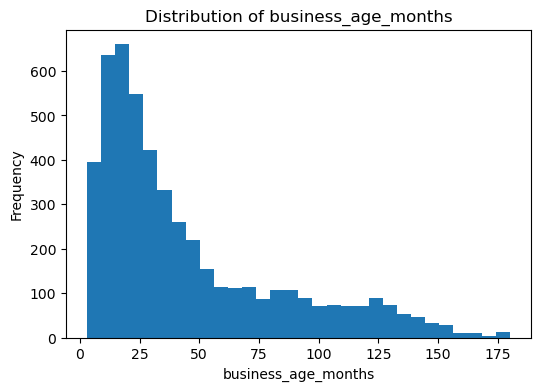

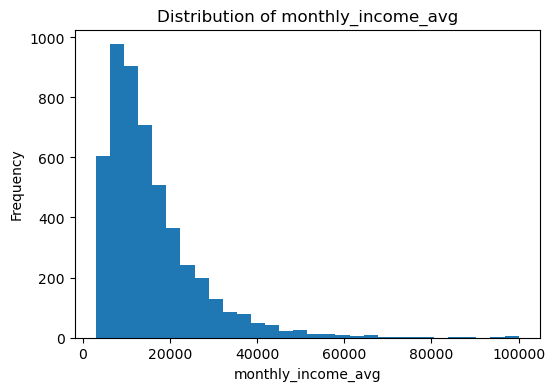

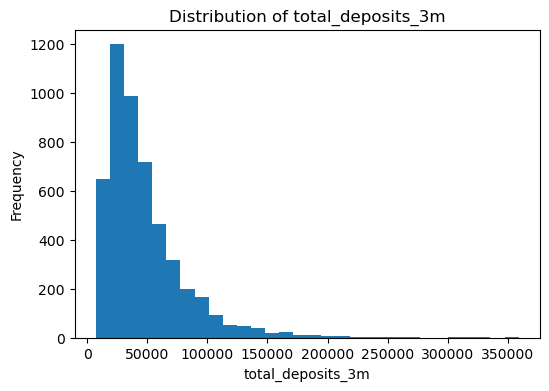

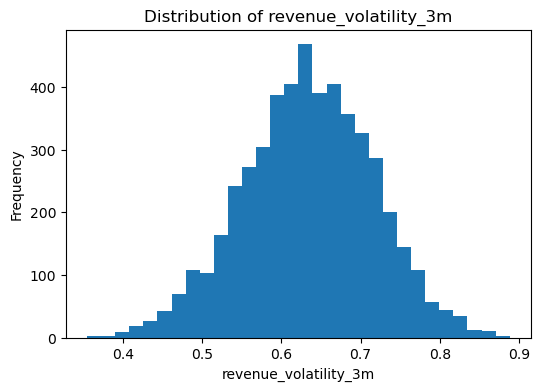

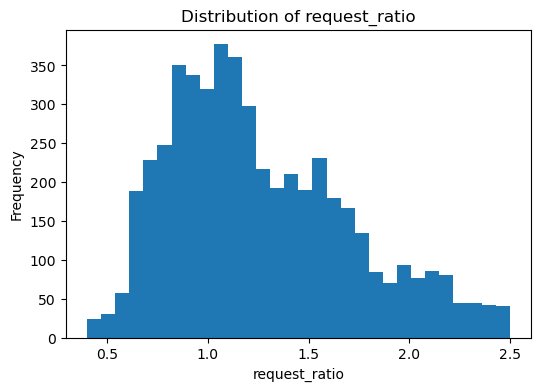

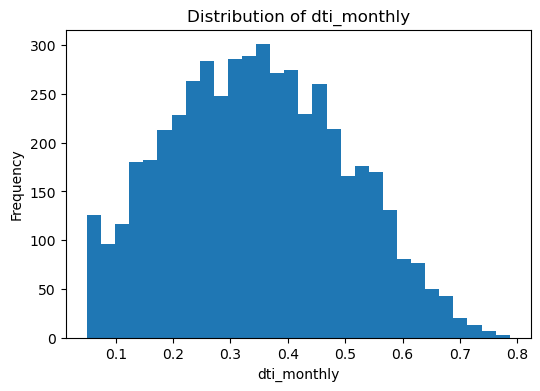

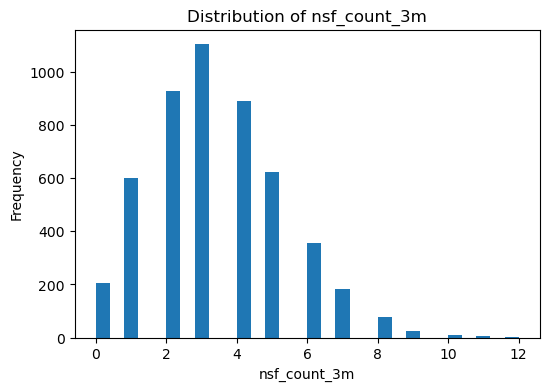

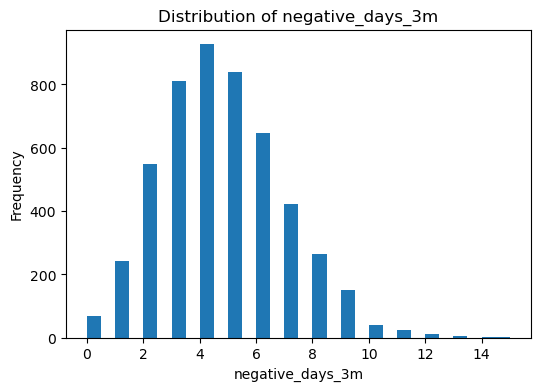

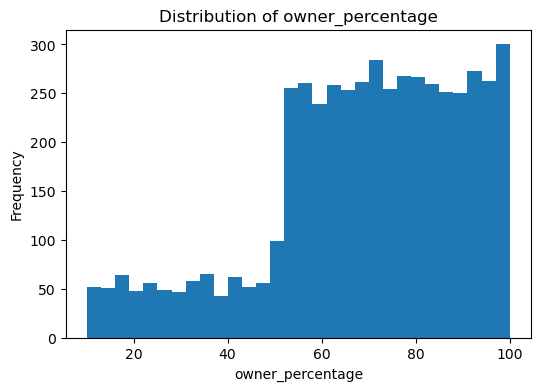

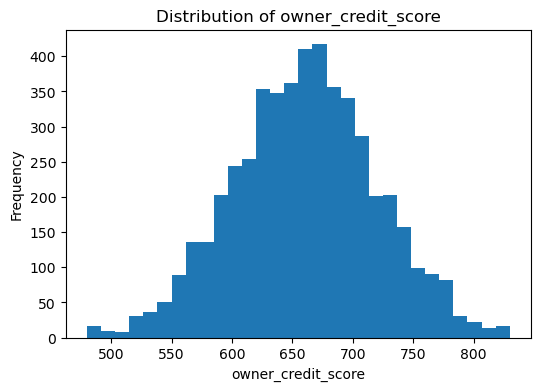

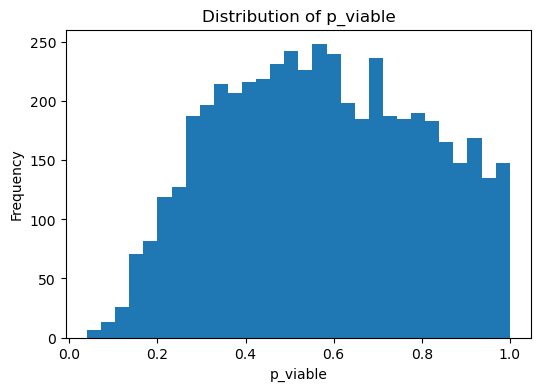

In [15]:
import matplotlib.pyplot as plt

columns = ['credit_amount', 'business_age_months', 'monthly_income_avg',
       'total_deposits_3m', 'revenue_volatility_3m', 'request_ratio',
       'dti_monthly', 'nsf_count_3m', 'negative_days_3m', 'owner_percentage',
       'owner_credit_score', 'p_viable']  

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

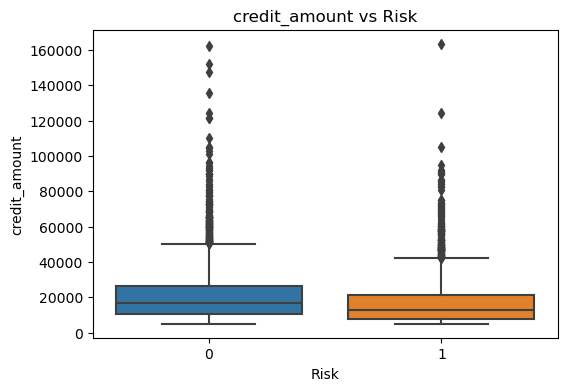

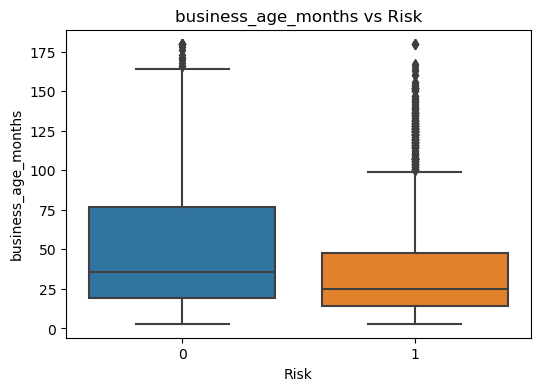

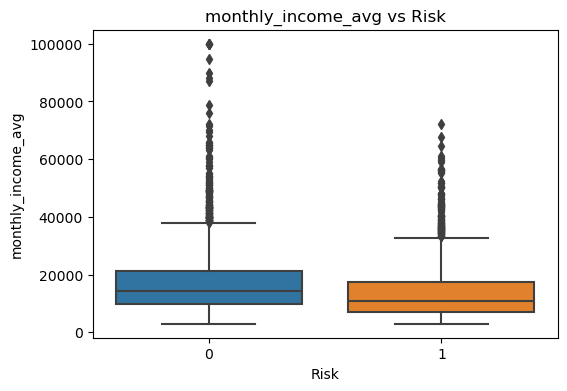

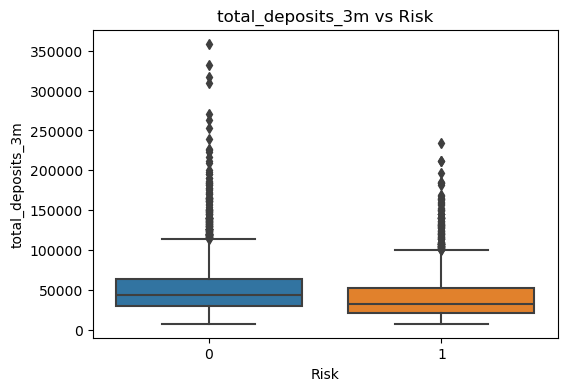

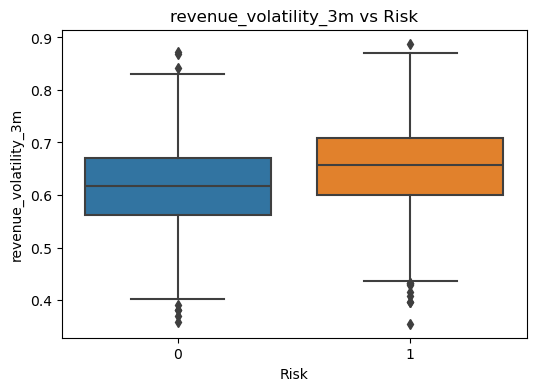

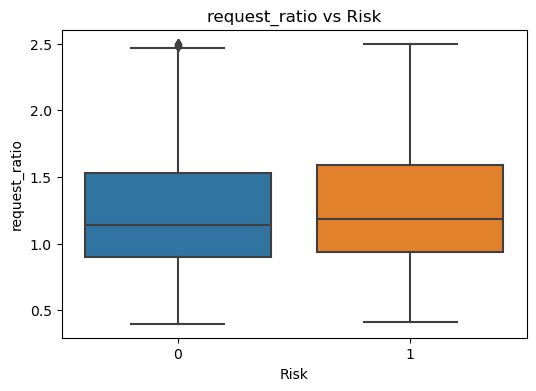

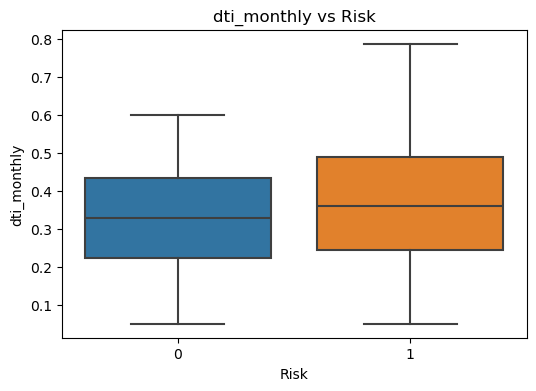

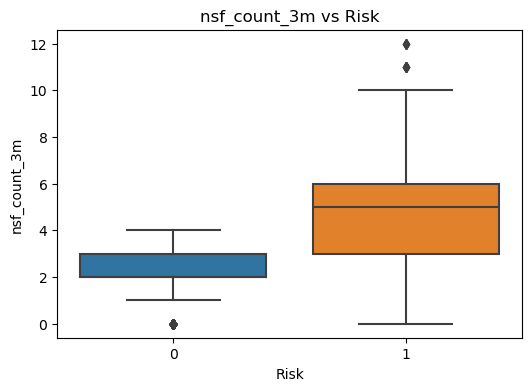

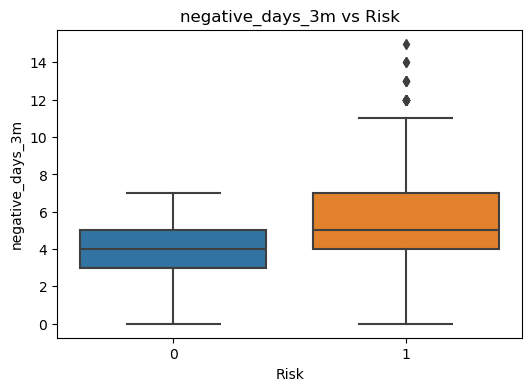

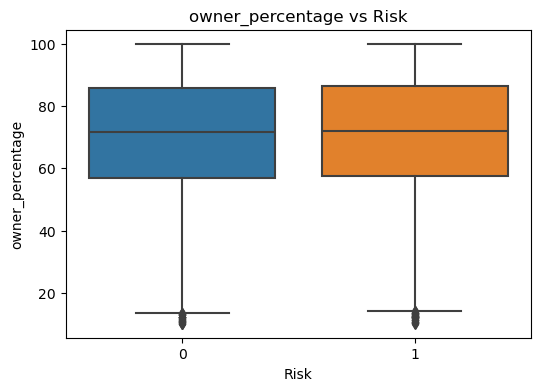

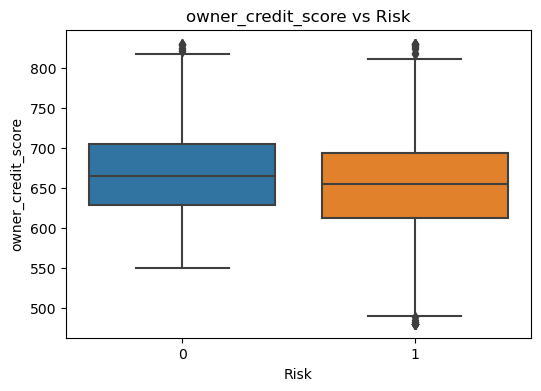

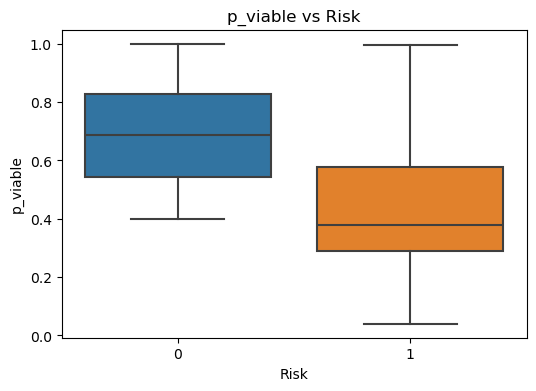

In [16]:
# الأعمدة الرقمية بس (ونشيل الـ target)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('risk_sharp', errors='ignore')

# loop على كل عمود
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='risk_sharp', y=col, data=df)
    plt.title(f"{col} vs Risk")
    plt.xlabel("Risk")
    plt.ylabel(col)
    plt.show()

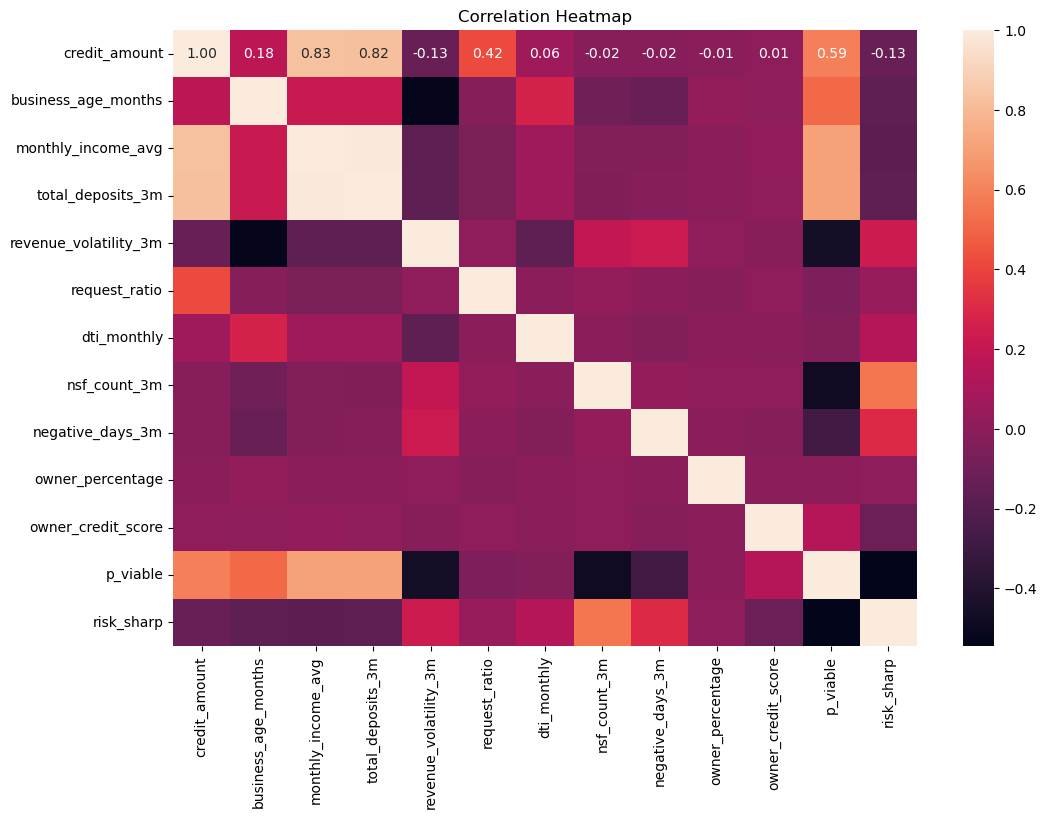

In [18]:
df_encoded = df.copy()
df_encoded['risk_sharp'] = df_encoded['risk_sharp'].astype('category').cat.codes

# نحسب الـ correlation
corr = df_encoded.corr()

# نرسم الـ heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()